# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

# Preprocesameinto de la variable objetivo 

Aplicar una transformación logarítmica a tu variable `casos_dengue` no solo es adecuado, sino que en este caso es **altamente recomendable**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [8]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\2_datos_procesados"
ubicacion_datos_consolidados_marco = ""
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos\05_ Preprocesamiento"
ubicacion_imagenes_marco = ""

In [4]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi.xlsx"
path_marco = r"C:\Users\marco\OneDrive - Universidad de Antioquia\Documentos\2_recursos_ensenanza\5_arima\6_datos_arima\4_base_datos_consolidada\datos_semanal_meteo_epi.xlsx"
df_semanal_meteo_epi = pd.read_excel(path_janis)
# hacer que fecha sea el indice y sea de tipo datetime
df_semanal_meteo_epi['fecha'] = pd.to_datetime(df_semanal_meteo_epi['fecha']) # convertir en tipo datetime
df_semanal_meteo_epi.set_index('fecha', inplace=True)  # hacer que fecha sea el indice 
df_semanal_meteo_epi.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst,casos_dengue
fecha,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214,0
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352,0
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407,1
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360,0
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892,0


In [5]:
df_semanal_meteo_epi.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue'],
      dtype='object')

In [6]:
df_semanal_meteo_epi['casos_dengue'] 

fecha
2021-01-03    0
2021-01-10    0
2021-01-17    1
2021-01-24    0
2021-01-31    0
             ..
2025-11-30    8
2025-12-07    9
2025-12-14    7
2025-12-21    5
2025-12-28    9
Name: casos_dengue, Length: 261, dtype: int64

In [10]:
# ====================== 1. COPIA DE SEGURIDAD ======================
df_procesados = df_semanal_meteo_epi.copy()

# ====================== 2. TRANSFORMACIONES DE NORMALIDAD ======================

# Logaritmo (para variables con muchos ceros)
df_procesados['casos_ln']       = np.log(df_procesados['casos_dengue'] + 1)
df_procesados['prec_ln']        = np.log(df_procesados['prec'] + 1)
df_procesados['dias_lluvia_ln'] = np.log(df_procesados['dias_lluvia'] + 1)

# Box-Cox para variables estrictamente positivas
vars_boxcox = ['temp', 'temp_max', 'temp_min', 'hum_esp', 'hum_rel',
               'vel_vi', 'vel_vi_max', 'vel_vi_min', 'uv']

for var in vars_boxcox:
    transformed, lam = boxcox(df_procesados[var])
    df_procesados[f'{var}_bc'] = transformed
    df_procesados[f'{var}_bc_lambda'] = lam   # Guardamos lambda

# Yeo-Johnson
pt_soi = PowerTransformer(method='yeo-johnson')
pt_sst = PowerTransformer(method='yeo-johnson')

df_procesados['soi_yj'] = pt_soi.fit_transform(df_procesados[['soi']])
df_procesados['sst_yj'] = pt_sst.fit_transform(df_procesados[['sst']])

print("✅ Transformaciones de normalidad aplicadas")

# ====================== 3. ESTANDARIZACIÓN ======================

variables_a_estandarizar = [
    'casos_ln', 'prec_ln', 'dias_lluvia_ln',
    'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc', 'hum_rel_bc',
    'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
    'soi_yj', 'sst_yj'
]

scaler = StandardScaler()

df_procesados[variables_a_estandarizar] = scaler.fit_transform(
    df_procesados[variables_a_estandarizar]
)

print("✅ Estandarización aplicada correctamente")

# ====================== 4. GUARDAR DOS VERSIONES DEL DATAFRAME ======================

# Asegurarnos que el índice sea de tipo datetime (por si acaso)
if not pd.api.types.is_datetime64_any_dtype(df_procesados.index):
    df_procesados.index = pd.to_datetime(df_procesados.index)

# Crear versión SIN lambda (más limpia para modelado)
df_sin_lambda = df_procesados.drop(
    columns=[col for col in df_procesados.columns if col.endswith('_lambda')]
).copy()

# Guardar versión SIN lambda
df_sin_lambda.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_procesados.xlsx", 
    index=True,                    # ← Importante: guardar el índice (fecha)
    sheet_name='datos_procesados'
)

# Guardar versión CON lambda (para invertir después)
df_procesados.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_procesados_con_lambda.xlsx", 
    index=True,                    # ← Guardar el índice (fecha)
    sheet_name='datos_procesados'
)

print("✅ Archivos guardados correctamente con fecha como índice:")
print(f"   → datos_procesados.xlsx   (sin columnas _lambda)")
print(f"   → datos_procesados_con_lambda.xlsx    (con lambdas guardados)")



✅ Transformaciones de normalidad aplicadas
✅ Estandarización aplicada correctamente
✅ Archivos guardados correctamente con fecha como índice:
   → datos_procesados.xlsx   (sin columnas _lambda)
   → datos_procesados_con_lambda.xlsx    (con lambdas guardados)


In [11]:
# Guardar solo las datos procesados sin originales ni lambdas
df_solo_procesados = df_procesados[variables_a_estandarizar].copy()
df_solo_procesados.to_excel(f"{ubicacion_datos_consolidados_janis}/df_solo_procesados.xlsx", index=False)
print("✅ Archivo df_solo_procesados.xlsx guardado con solo las variables estandarizadas (sin índice ni lambdas)")


✅ Archivo df_solo_procesados.xlsx guardado con solo las variables estandarizadas (sin índice ni lambdas)


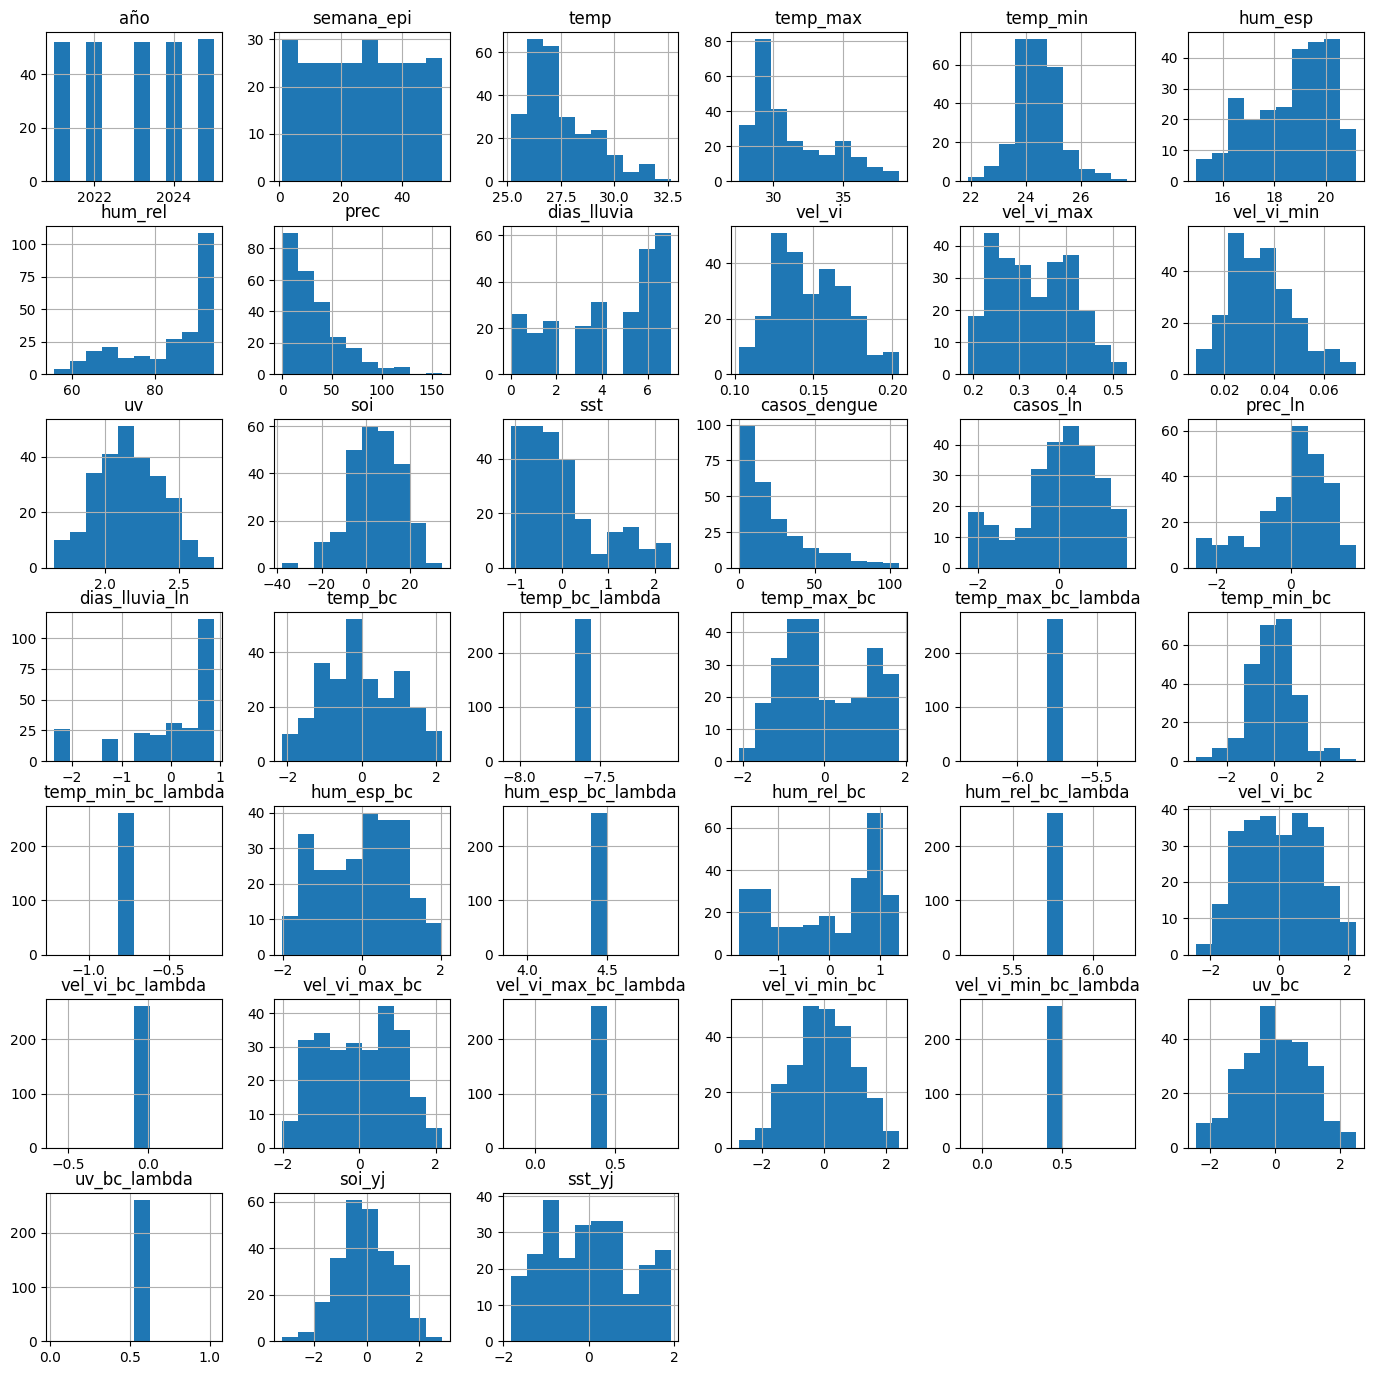

In [ ]:
# Histogramas de todas las variables transformadas y estandarizadas sin las columnas de lambda
df_procesados.hist(figsize=(17,17))
plt.savefig(f"{ubicacion_imagenes_janis}/1.histogramas_procesados_sin_rezagos.png")
plt.show() 

In [ ]:
df_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_bc_lambda', 'temp_max_bc',
       'temp_max_bc_lambda', 'temp_min_bc', 'temp_min_bc_lambda', 'hum_esp_bc',
       'hum_esp_bc_lambda', 'hum_rel_bc', 'hum_rel_bc_lambda', 'vel_vi_bc',
       'vel_vi_bc_lambda', 'vel_vi_max_bc', 'vel_vi_max_bc_lambda',
       'vel_vi_min_bc', 'vel_vi_min_bc_lambda', 'uv_bc', 'uv_bc_lambda',
       'soi_yj', 'sst_yj'],
      dtype='object')

In [ ]:
df_procesados.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,vel_vi_bc,vel_vi_bc_lambda,vel_vi_max_bc,vel_vi_max_bc_lambda,vel_vi_min_bc,vel_vi_min_bc_lambda,uv_bc,uv_bc_lambda,soi_yj,sst_yj
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,-1.110633,-0.087219,-0.752514,0.347244,0.970687,0.410272,0.284735,0.525184,1.432593,-1.726035
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,-1.864950,-0.087219,-1.741631,0.347244,0.390308,0.410272,0.424653,0.525184,1.251647,-1.721237
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,-1.190152,-0.087219,-1.369313,0.347244,0.878558,0.410272,1.147566,0.525184,0.545162,-1.403882
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,-1.190152,-0.087219,-1.482924,0.347244,0.180094,0.410272,1.391362,0.525184,0.983127,-1.181283
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,-1.518601,-0.087219,-1.391847,0.347244,-0.272288,0.410272,0.582532,0.525184,0.403642,-1.323334


Calculando correlaciones cruzadas...



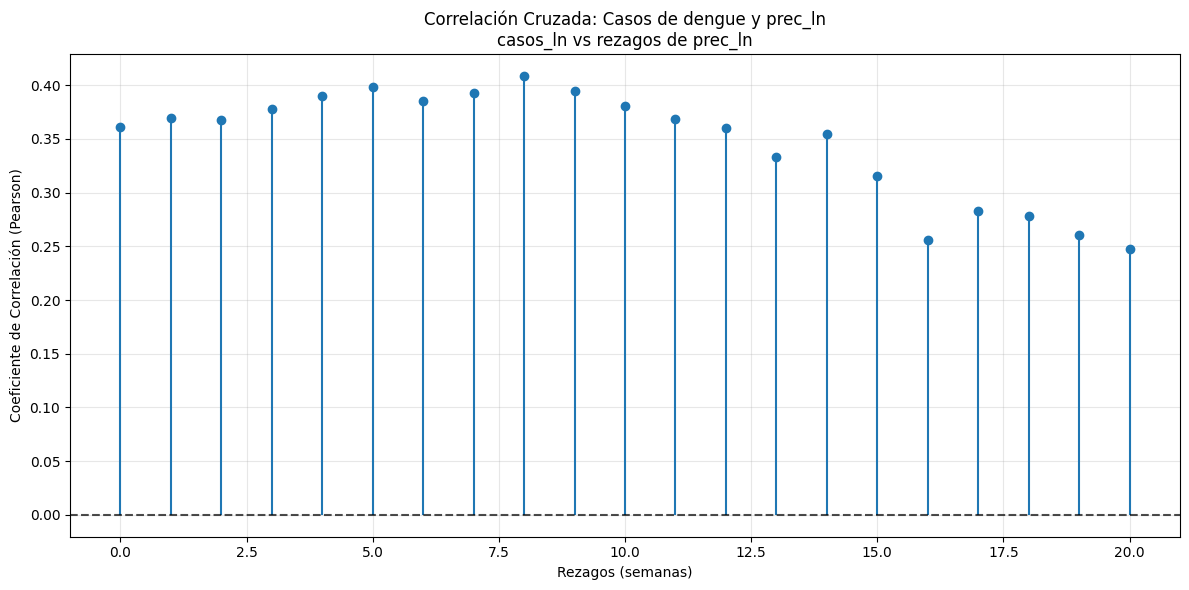


=== Rezagos más relevantes para casos_ln vs prec_ln ===
Lag  0: +0.3615
Lag  1: +0.3693
Lag  2: +0.3675
Lag  3: +0.3779
Lag  4: +0.3899
Lag  5: +0.3985
Lag  6: +0.3853
Lag  7: +0.3932
Lag  8: +0.4088
Lag  9: +0.3950
Lag 10: +0.3804
Lag 11: +0.3685
Lag 12: +0.3598
Lag 13: +0.3333
Lag 14: +0.3547
Lag 15: +0.3159
Lag 16: +0.2562
Lag 17: +0.2826
Lag 18: +0.2782
Lag 19: +0.2604
Lag 20: +0.2472
------------------------------------------------------------


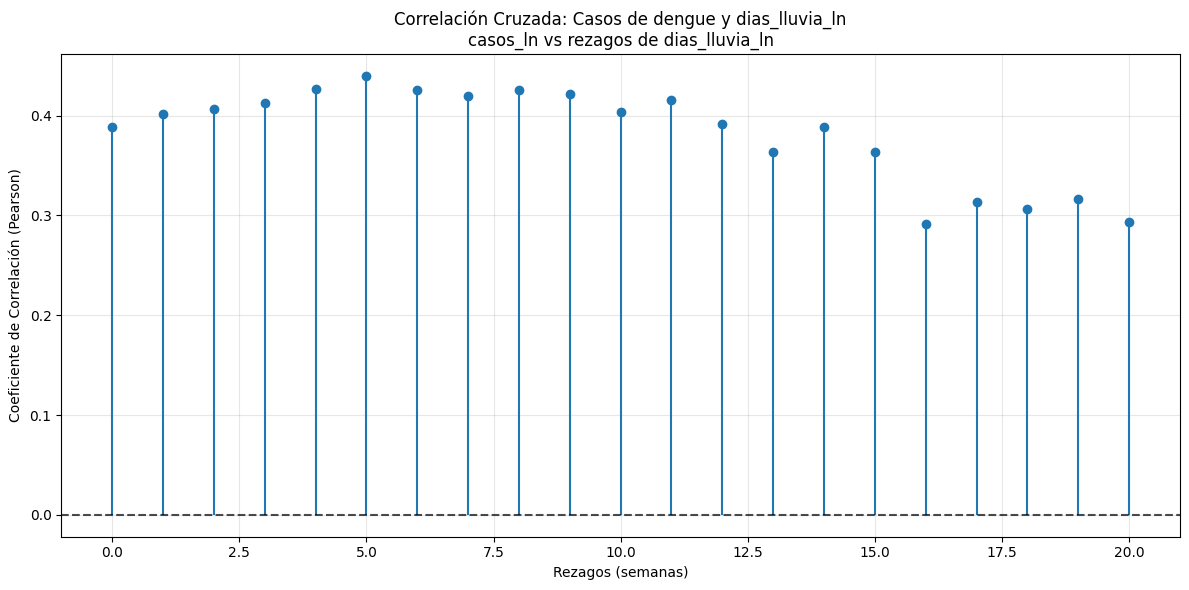


=== Rezagos más relevantes para casos_ln vs dias_lluvia_ln ===
Lag  0: +0.3886
Lag  1: +0.4016
Lag  2: +0.4066
Lag  3: +0.4128
Lag  4: +0.4265
Lag  5: +0.4399
Lag  6: +0.4254
Lag  7: +0.4198
Lag  8: +0.4260
Lag  9: +0.4221
Lag 10: +0.4039
Lag 11: +0.4158
Lag 12: +0.3913
Lag 13: +0.3640
Lag 14: +0.3884
Lag 15: +0.3635
Lag 16: +0.2912
Lag 17: +0.3133
Lag 18: +0.3066
Lag 19: +0.3164
Lag 20: +0.2934
------------------------------------------------------------


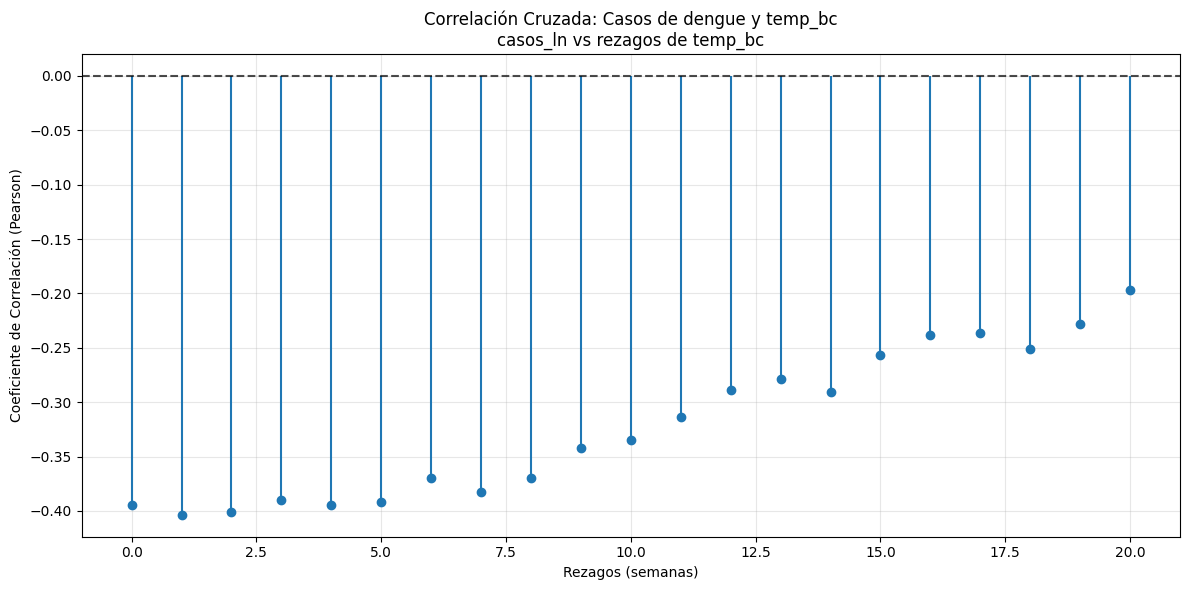


=== Rezagos más relevantes para casos_ln vs temp_bc ===
Lag  0: -0.3946
Lag  1: -0.4035
Lag  2: -0.4008
Lag  3: -0.3897
Lag  4: -0.3948
Lag  5: -0.3918
Lag  6: -0.3695
Lag  7: -0.3823
Lag  8: -0.3694
Lag  9: -0.3417
Lag 10: -0.3343
Lag 11: -0.3135
Lag 12: -0.2887
Lag 13: -0.2790
Lag 14: -0.2907
Lag 15: -0.2564
Lag 16: -0.2386
Lag 17: -0.2364
Lag 18: -0.2514
Lag 19: -0.2283
------------------------------------------------------------


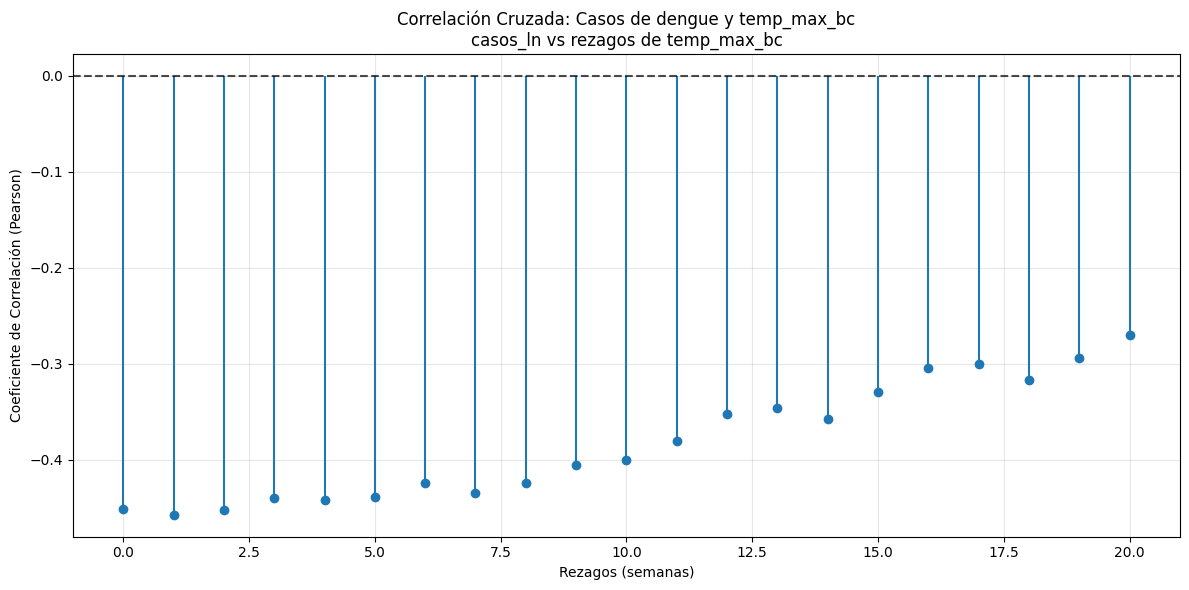


=== Rezagos más relevantes para casos_ln vs temp_max_bc ===
Lag  0: -0.4512
Lag  1: -0.4573
Lag  2: -0.4519
Lag  3: -0.4397
Lag  4: -0.4420
Lag  5: -0.4391
Lag  6: -0.4237
Lag  7: -0.4350
Lag  8: -0.4246
Lag  9: -0.4053
Lag 10: -0.4001
Lag 11: -0.3801
Lag 12: -0.3522
Lag 13: -0.3458
Lag 14: -0.3574
Lag 15: -0.3293
Lag 16: -0.3046
Lag 17: -0.2998
Lag 18: -0.3167
Lag 19: -0.2943
Lag 20: -0.2705
------------------------------------------------------------


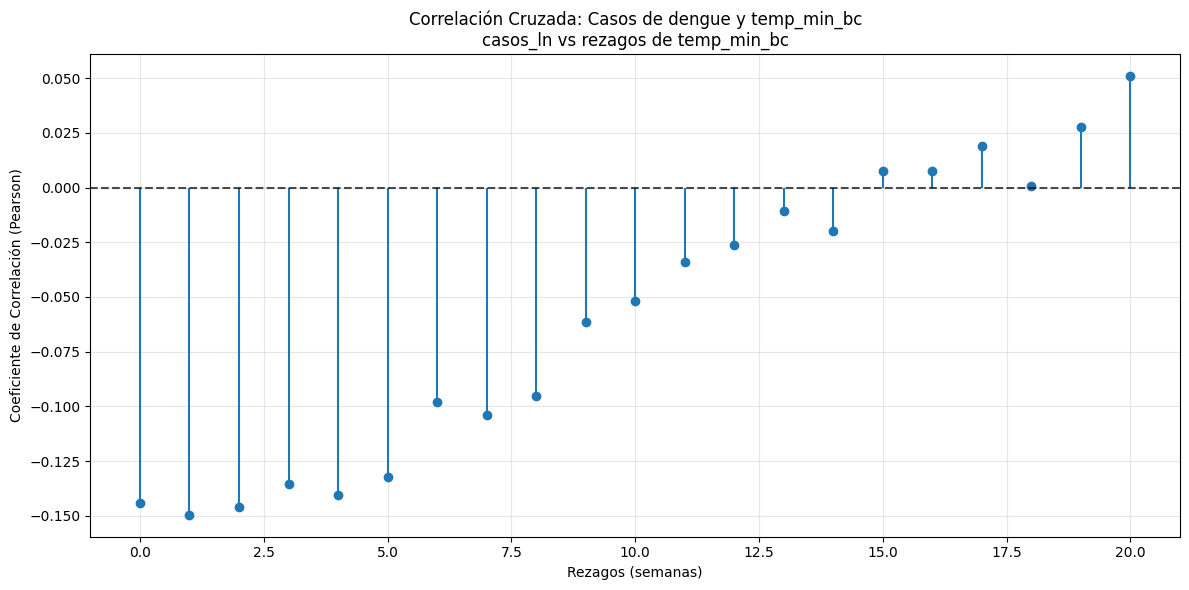


=== Rezagos más relevantes para casos_ln vs temp_min_bc ===
------------------------------------------------------------


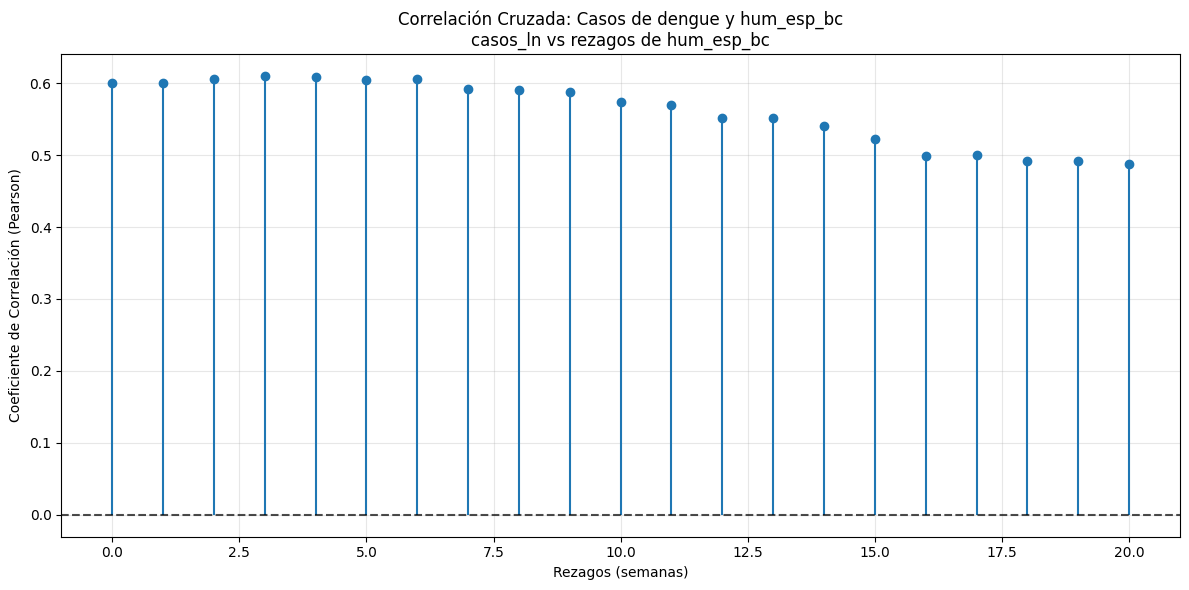


=== Rezagos más relevantes para casos_ln vs hum_esp_bc ===
Lag  0: +0.6003
Lag  1: +0.6005
Lag  2: +0.6056
Lag  3: +0.6102
Lag  4: +0.6089
Lag  5: +0.6047
Lag  6: +0.6061
Lag  7: +0.5923
Lag  8: +0.5908
Lag  9: +0.5879
Lag 10: +0.5740
Lag 11: +0.5693
Lag 12: +0.5514
Lag 13: +0.5511
Lag 14: +0.5406
Lag 15: +0.5218
Lag 16: +0.4988
Lag 17: +0.4995
Lag 18: +0.4921
Lag 19: +0.4920
Lag 20: +0.4875
------------------------------------------------------------


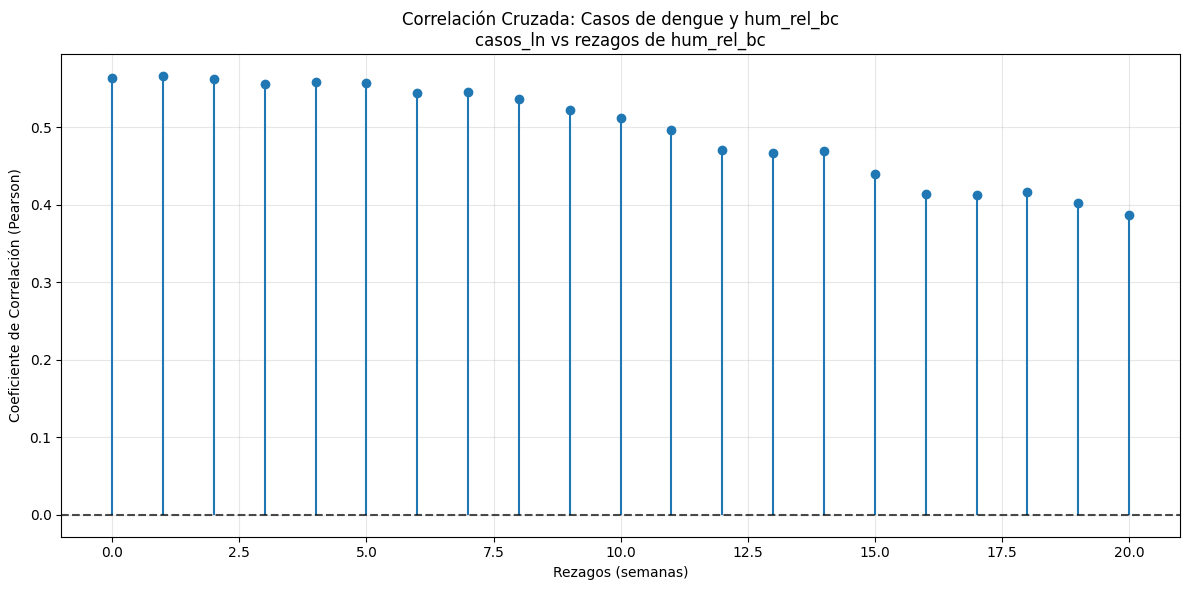


=== Rezagos más relevantes para casos_ln vs hum_rel_bc ===
Lag  0: +0.5637
Lag  1: +0.5663
Lag  2: +0.5625
Lag  3: +0.5564
Lag  4: +0.5590
Lag  5: +0.5572
Lag  6: +0.5448
Lag  7: +0.5458
Lag  8: +0.5363
Lag  9: +0.5222
Lag 10: +0.5119
Lag 11: +0.4959
Lag 12: +0.4712
Lag 13: +0.4670
Lag 14: +0.4694
Lag 15: +0.4398
Lag 16: +0.4134
Lag 17: +0.4131
Lag 18: +0.4158
Lag 19: +0.4024
Lag 20: +0.3863
------------------------------------------------------------


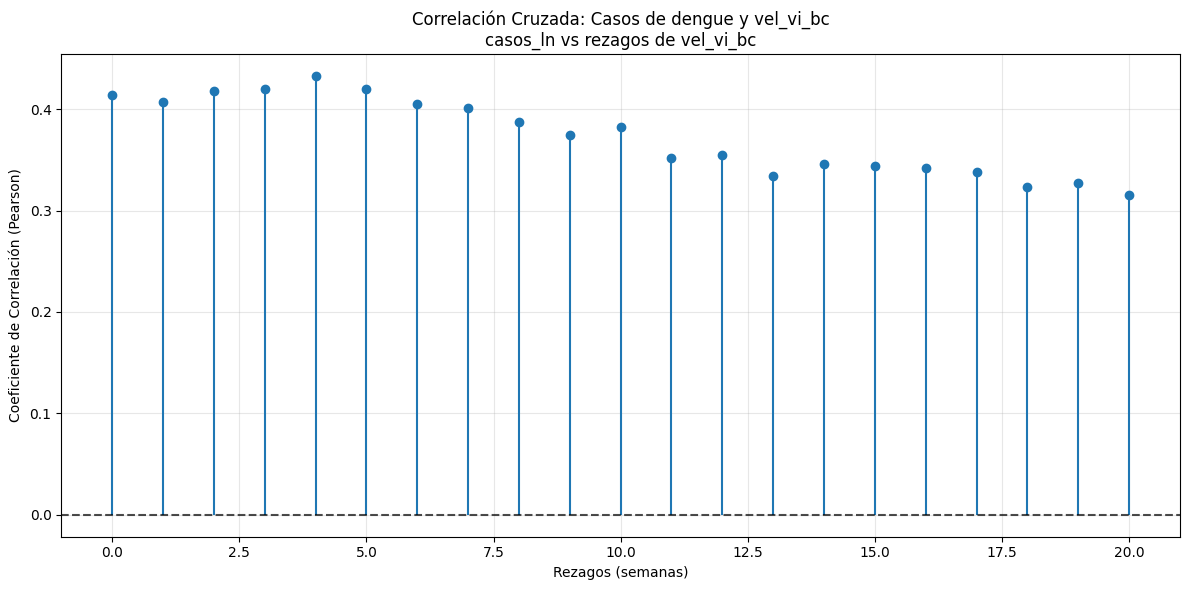


=== Rezagos más relevantes para casos_ln vs vel_vi_bc ===
Lag  0: +0.4135
Lag  1: +0.4066
Lag  2: +0.4176
Lag  3: +0.4199
Lag  4: +0.4328
Lag  5: +0.4204
Lag  6: +0.4056
Lag  7: +0.4014
Lag  8: +0.3874
Lag  9: +0.3742
Lag 10: +0.3821
Lag 11: +0.3519
Lag 12: +0.3547
Lag 13: +0.3341
Lag 14: +0.3454
Lag 15: +0.3444
Lag 16: +0.3415
Lag 17: +0.3383
Lag 18: +0.3228
Lag 19: +0.3269
Lag 20: +0.3153
------------------------------------------------------------


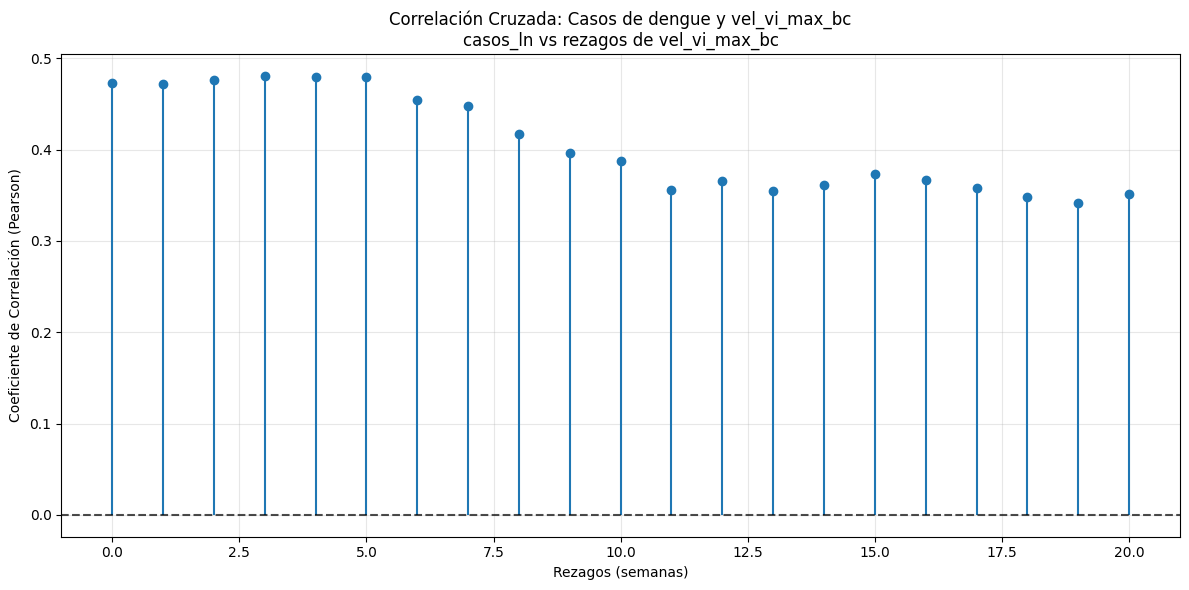


=== Rezagos más relevantes para casos_ln vs vel_vi_max_bc ===
Lag  0: +0.4727
Lag  1: +0.4716
Lag  2: +0.4764
Lag  3: +0.4809
Lag  4: +0.4799
Lag  5: +0.4793
Lag  6: +0.4541
Lag  7: +0.4476
Lag  8: +0.4172
Lag  9: +0.3960
Lag 10: +0.3882
Lag 11: +0.3559
Lag 12: +0.3662
Lag 13: +0.3547
Lag 14: +0.3617
Lag 15: +0.3729
Lag 16: +0.3667
Lag 17: +0.3586
Lag 18: +0.3486
Lag 19: +0.3419
Lag 20: +0.3512
------------------------------------------------------------


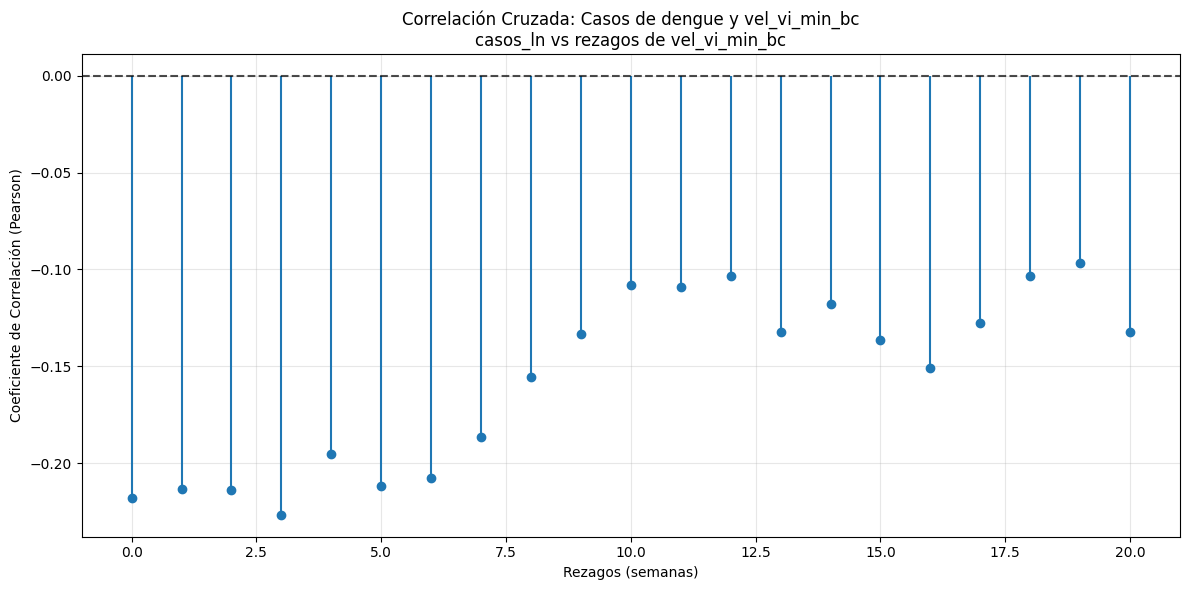


=== Rezagos más relevantes para casos_ln vs vel_vi_min_bc ===
Lag  0: -0.2178
Lag  1: -0.2136
Lag  2: -0.2137
Lag  3: -0.2267
Lag  5: -0.2117
Lag  6: -0.2075
------------------------------------------------------------


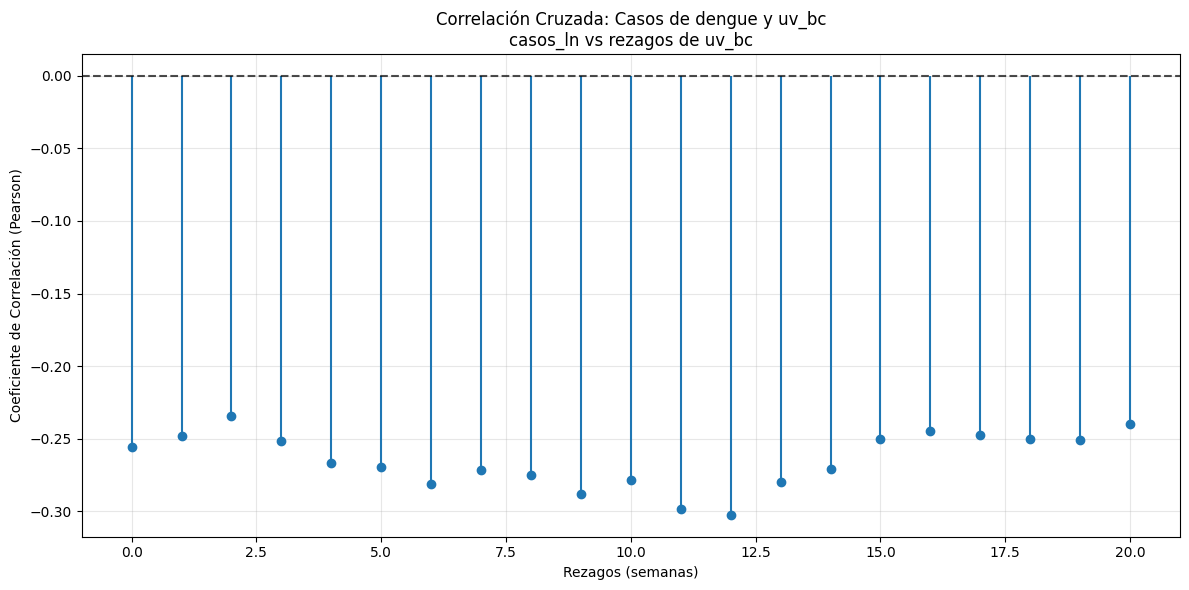


=== Rezagos más relevantes para casos_ln vs uv_bc ===
Lag  0: -0.2554
Lag  1: -0.2484
Lag  2: -0.2342
Lag  3: -0.2516
Lag  4: -0.2665
Lag  5: -0.2695
Lag  6: -0.2814
Lag  7: -0.2717
Lag  8: -0.2749
Lag  9: -0.2880
Lag 10: -0.2782
Lag 11: -0.2985
Lag 12: -0.3024
Lag 13: -0.2799
Lag 14: -0.2707
Lag 15: -0.2505
Lag 16: -0.2448
Lag 17: -0.2475
Lag 18: -0.2505
Lag 19: -0.2511
Lag 20: -0.2401
------------------------------------------------------------


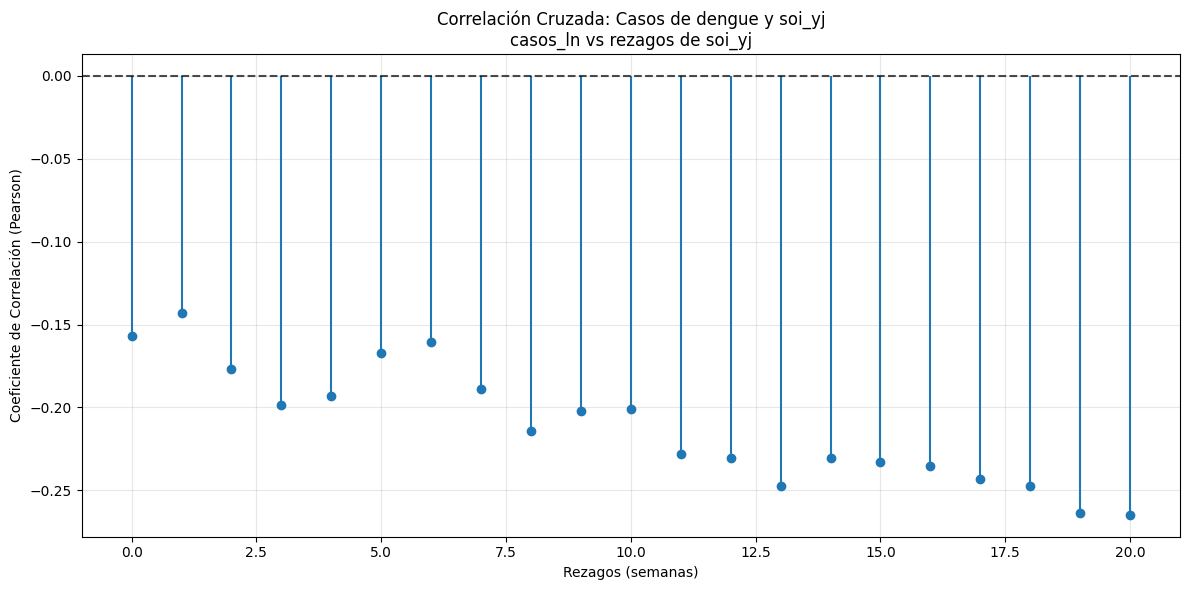


=== Rezagos más relevantes para casos_ln vs soi_yj ===
Lag  8: -0.2145
Lag  9: -0.2019
Lag 10: -0.2010
Lag 11: -0.2280
Lag 12: -0.2303
Lag 13: -0.2473
Lag 14: -0.2306
Lag 15: -0.2330
Lag 16: -0.2350
Lag 17: -0.2432
Lag 18: -0.2471
Lag 19: -0.2635
Lag 20: -0.2647
------------------------------------------------------------


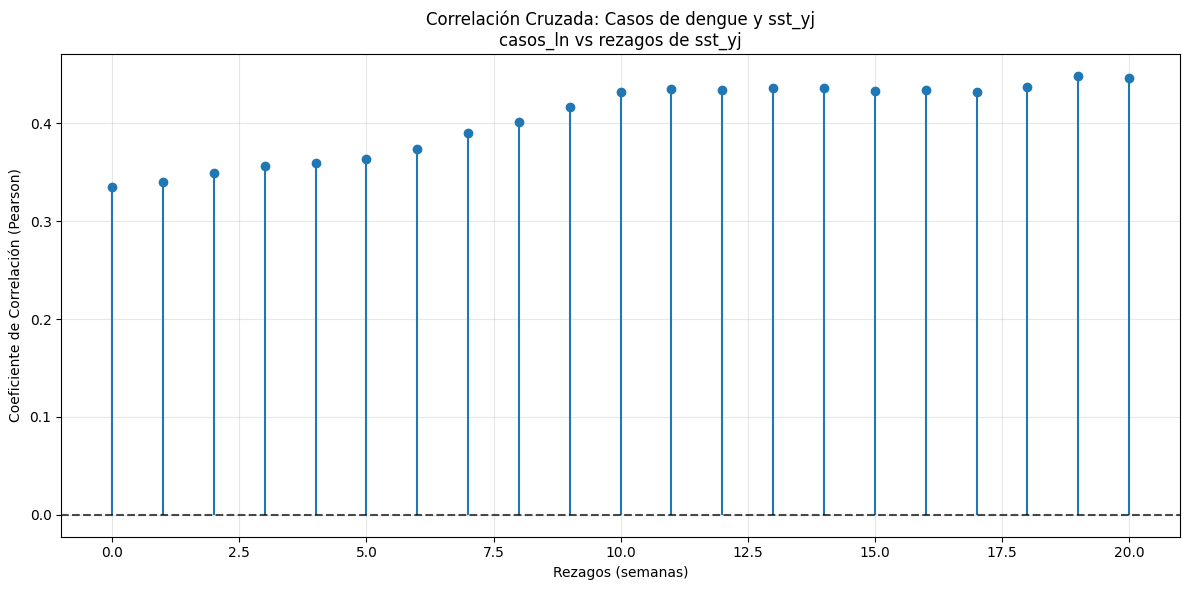


=== Rezagos más relevantes para casos_ln vs sst_yj ===
Lag  0: +0.3349
Lag  1: +0.3397
Lag  2: +0.3492
Lag  3: +0.3561
Lag  4: +0.3601
Lag  5: +0.3642
Lag  6: +0.3738
Lag  7: +0.3899
Lag  8: +0.4017
Lag  9: +0.4165
Lag 10: +0.4326
Lag 11: +0.4350
Lag 12: +0.4341
Lag 13: +0.4367
Lag 14: +0.4367
Lag 15: +0.4328
Lag 16: +0.4344
Lag 17: +0.4320
Lag 18: +0.4371
Lag 19: +0.4487
Lag 20: +0.4467
------------------------------------------------------------


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== FUNCIÓN CORREGIDA Y LIMPIA ====================== 
def plot_cross_correlation_corrected(df, var_x, var_y, max_lags=20, title="", save_path=None):
    """
    Calcula correlación cruzada usando Pearson correctamente por cada lag.
    """
    x = df[var_x].dropna().values
    y = df[var_y].dropna().values
    
    if len(x) < max_lags + 10:
        print(f"Advertencia: Pocos datos ({len(x)}) para {var_x}")
    
    corr_values = []
    lags = range(max_lags + 1)
    
    for lag in lags:
        if lag == 0:
            corr = np.corrcoef(x, y)[0, 1]
        else:
            if lag >= len(x):
                corr = np.nan
            else:
                corr = np.corrcoef(x[:-lag], y[lag:])[0, 1]
        corr_values.append(corr)
    
    # Graficar
    plt.figure(figsize=(12, 6))
    plt.stem(lags, corr_values, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
    plt.title(f'Correlación Cruzada: {title}\n{var_y} vs rezagos de {var_x}')
    plt.xlabel('Rezagos (semanas)')
    plt.ylabel('Coeficiente de Correlación (Pearson)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()
    
    # Mostrar rezagos relevantes
    print(f"\n=== Rezagos más relevantes para {var_y} vs {var_x} ===")
    for i, corr in enumerate(corr_values):
        if abs(corr) > 0.20 and not np.isnan(corr):   # subí umbral a 0.20 para menos ruido
            print(f"Lag {i:2d}: {corr:+.4f}")
    print("-" * 60)


# ====================== EJECUCIÓN ====================== 
variables_a_analizar = [
    'prec_ln', 'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc',
    'hum_esp_bc', 'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc',
    'uv_bc', 'soi_yj', 'sst_yj'
]

print("Calculando correlaciones cruzadas...\n")

for var in variables_a_analizar:
    save_path = f"{ubicacion_imagenes_janis}/2.ccf_casos_dengue_{var}.png"
    plot_cross_correlation_corrected(
        df=df_procesados,
        var_x=var,
        var_y='casos_ln',
        max_lags=20,
        title=f"Casos de dengue y {var}",
        save_path=save_path
    )

In [13]:
# Guardar en archivo de texto los rezagos relevantes encontrados
with open(f"{ubicacion_datos_consolidados_janis}/rezagos_relevantes.txt", "w") as f:
    f.write("=== Rezagos Relevantes para Casos de Dengue ===\n\n")
    for var in variables_a_analizar:
        f.write(f"Variable: {var}\n")
        x = df_procesados[var].dropna().values
        y = df_procesados['casos_ln'].dropna().values
        corr_values = []
        for lag in range(21):
            if lag == 0:
                corr = np.corrcoef(x, y)[0, 1]
            else:
                if lag >= len(x):
                    corr = np.nan
                else:
                    corr = np.corrcoef(x[:-lag], y[lag:])[0, 1]
            corr_values.append(corr)
        
        for i, corr in enumerate(corr_values):
            if abs(corr) > 0.20 and not np.isnan(corr):
                f.write(f"  Lag {i:2d}: {corr:+.4f}\n")
        f.write("-" * 40 + "\n")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# FUNCIÓN DE CORRELACIÓN CRUZADA
# ==========================================

def correlacion_cruzada(serie_x, serie_y, max_lag=20):
    """
    Calcula correlaciones cruzadas para distintos rezagos.

    serie_x = variable antecedente (ej: SST)
    serie_y = variable respuesta (ej: temperatura)

    lag positivo:
    X(t-k) -> Y(t)
    """

    resultados = []

    for lag in range(max_lag + 1):

        corr = serie_x.shift(lag).corr(serie_y)

        resultados.append({
            'lag': lag,
            'correlacion': corr
        })

    return pd.DataFrame(resultados)

# ==========================================
# EJEMPLOS
# ==========================================

# SST vs Temperatura
ccf_temp = correlacion_cruzada(
    df_procesados['sst_yj'],
    df_procesados['temp_bc'],
    max_lag=20
)

# SST vs Precipitación
ccf_prec = correlacion_cruzada(
    df_procesados['sst_yj'],
    df_procesados['prec_ln'],
    max_lag=20
)

# SST vs Casos dengue
ccf_casos = correlacion_cruzada(
    df_procesados['sst_yj'],
    df_procesados['casos_ln'],
    max_lag=20
)

# ==========================================
# MOSTRAR RESULTADOS
# ==========================================

print("\n=== SST vs Temperatura ===")
print(ccf_temp)

print("\n=== SST vs Precipitación ===")
print(ccf_prec)

print("\n=== SST vs Casos Dengue ===")
print(ccf_casos)

# ==========================================
# GRAFICAR
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    ccf_temp['lag'],
    ccf_temp['correlacion'],
    marker='o',
    label='SST vs Temperatura'
)

plt.plot(
    ccf_prec['lag'],
    ccf_prec['correlacion'],
    marker='o',
    label='SST vs Precipitación'
)

plt.plot(
    ccf_casos['lag'],
    ccf_casos['correlacion'],
    marker='o',
    label='SST vs Casos'
)

plt.axhline(0, color='black', linestyle='--')

plt.xlabel('Rezago (semanas)')
plt.ylabel('Correlación')
plt.title('Correlación cruzada con SST')

plt.legend()

plt.grid(True)

plt.show()

In [14]:
df_semanal_meteo_epi.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue'],
      dtype='object')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo (igual al de tu imagen)
sns.set(style="whitegrid")

# Diccionario de variables
variables_hist = {
    'casos_dengue': 'casos_ln',
    'prec': 'prec_ln',
    'dias_lluvia': 'dias_lluvia_ln',
    'temp': 'temp_bc',
    'temp_max': 'temp_max_bc',
    'temp_min': 'temp_min_bc',
    'hum_esp': 'hum_esp_bc',
    'hum_rel': 'hum_rel_bc',
    'vel_vi': 'vel_vi_bc',
    'vel_vi_max': 'vel_vi_max_bc',
    'vel_vi_min': 'vel_vi_min_bc',
    'uv': 'uv_bc',
    'soi': 'soi_yj',
    'sst': 'sst_yj',
}

# ====================== Histogramas tipo publicación ======================
for var_original, var_transformada in variables_hist.items():
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 🔵 ORIGINAL
    sns.histplot(
        df_semanal_meteo_epi[var_original].dropna(),
        bins=20,
        kde=True,
        ax=axes[0],
        color="skyblue"
    )
    axes[0].set_title(f'Distribución Original: {var_original}')
    axes[0].set_xlabel(var_original)
    axes[0].set_ylabel('Frecuencia')
    
    # 🔴 TRANSFORMADA
    sns.histplot(
        df_procesados[var_transformada].dropna(),
        bins=20,
        kde=True,
        ax=axes[1],
        color="salmon"
    )
    axes[1].set_title(f'Distribución Transformada: {var_transformada}')
    axes[1].set_xlabel(var_transformada)
    axes[1].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    
    # Guardar imagen
    save_path = f"{ubicacion_imagenes_janis}/3.histograma_{var_original}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    plt.close()


## Prueba de normalidad

In [16]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_procesados.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi', 'temp_bc_lambda', 'temp_max_bc_lambda', 'temp_min_bc_lambda', 'hum_esp_bc_lambda', 'hum_rel_bc_lambda', 'vel_vi_bc_lambda', 'vel_vi_max_bc_lambda', 'vel_vi_min_bc_lambda', 'uv_bc_lambda'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.917537,8.004622e-11,False
temp_max,0.883120,2.825387e-13,False
temp_min,0.980537,1.226305e-03,False
hum_esp,0.948490,5.846115e-08,False
hum_rel,0.830594,3.401543e-16,False
prec,0.890732,8.840685e-13,False
dias_lluvia,0.880142,1.833430e-13,False
vel_vi,0.977046,3.204057e-04,False
vel_vi_max,0.964436,4.612705e-06,False
vel_vi_min,0.975928,2.120517e-04,False


## Se aplicará VIF para detectar multicolinealidad entre las variables transformadas y estandarizadas, y así decidir cuáles incluir en el modelo ARIMA con rezagos.

In [19]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================
# VIF DE TODAS LAS VARIABLES
# ============================

# Seleccionar solo columnas numéricas
X = df_procesados.select_dtypes(include=[np.number]).copy()

# Eliminar columnas que tengan un solo valor (constantes) → causan VIF infinito
X = X.loc[:, X.nunique() > 1]

# Eliminar filas con NaN
X = X.dropna()

print(f"Dimensiones del dataframe para VIF: {X.shape}")

# Agregar constante
X_const = add_constant(X)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# Ordenar de mayor a menor VIF
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

# Mostrar resultados
print("🔍 MULTICOLINEALIDAD - VIF DE TODAS LAS VARIABLES")
print("="*70)
print(vif_data.round(2))

# Resumen por niveles de problema
print("\n" + "="*70)
print("RESUMEN DE PROBLEMAS:")
print(vif_data[vif_data['VIF'] > 10][['Variable', 'VIF']])

Dimensiones del dataframe para VIF: (261, 30)
🔍 MULTICOLINEALIDAD - VIF DE TODAS LAS VARIABLES
          Variable          VIF
0            const  11531673.68
1          hum_rel      6060.08
2             temp      2722.72
3          hum_esp      2024.75
4         temp_min      1928.58
5      temp_min_bc      1798.22
6            uv_bc      1419.00
7               uv      1407.54
8         temp_max       696.54
9    vel_vi_max_bc       536.86
10      vel_vi_max       491.14
11      hum_rel_bc       465.52
12      hum_esp_bc       351.75
13       vel_vi_bc       340.63
14         temp_bc       308.53
15          vel_vi       305.50
16     temp_max_bc       271.67
17             soi       203.44
18          soi_yj       203.24
19      vel_vi_min        68.24
20   vel_vi_min_bc        64.35
21  dias_lluvia_ln        40.51
22     dias_lluvia        26.54
23          sst_yj        22.97
24         prec_ln        22.68
25             sst        21.49
26        casos_ln         9.78
27       

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Variables seleccionadas (ajusta según lo que quieras probar)
variables_seleccionadas = [
    'hum_esp_bc', 
    'temp_max_bc',
    'dias_lluvia_ln',
    'Vel_vi_bc',
    'vel_vi_max_bc',
    'sst_yj'          # opcional
]

X = df_procesados[variables_seleccionadas].copy()
X = X.dropna()

X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data.round(2))

## A continuacion, se harán los rezagos según la recomendación dada por la correlación cruzada Y VIF, para cada variable exógena. Se crearán nuevas columnas con el formato "variable_lagX" donde X es el número de semanas de rezago.

In [10]:
print(df_procesados.index.name)

fecha


### Base de datos con variables que tuvieron significancia del 95%, con los rezagos más importantes que se encontraron en el análisis de correlación cruzada

In [13]:
# =========================================================
# 1. CREAR DATAFRAME SOLO CON VARIABLES NECESARIAS
# =========================================================

datos_procesados_rezagos = df_sin_lambda[[
    'año',
    'semana_epi',
    'casos_ln',
    'hum_esp_bc',
    'hum_rel_bc',
    'vel_vi_max_bc',
    'temp_max_bc',
    'vel_vi_bc',
    'dias_lluvia_ln',
    'prec_ln',
    'temp_bc',
    'sst_yj'
]].copy()

# =========================================================
# 2. ASEGURAR QUE LA FECHA ESTÉ COMO ÍNDICE
# =========================================================

if not pd.api.types.is_datetime64_any_dtype(datos_procesados_rezagos.index):
    datos_procesados_rezagos.index = pd.to_datetime(
        datos_procesados_rezagos.index
    )

# Convertir índice a columna llamada fecha
datos_procesados_rezagos.reset_index(inplace=True)

# Renombrar columna índice
datos_procesados_rezagos.rename(
    columns={'index': 'fecha'},
    inplace=True
)

print("✅ Columnas fecha, año y semana_epi agregadas")


# =========================================================
# 3. CREACIÓN DE REZAGOS (SELECCIÓN DIRIGIDA)
# =========================================================

# Diccionario con rezagos seleccionados
lags_dict = {
    'hum_esp_bc': [1, 3, 6],
    'prec_ln': [1, 4, 5, 8],
    'temp_max_bc': [1, 3, 5, 7],
    'vel_vi_max_bc': [2, 3, 5],
    'sst_yj': [8, 10, 12, 16],
}

# Crear rezagos
for var, lags in lags_dict.items():
    for lag in lags:
        datos_procesados_rezagos[f"{var}_lag_{lag}"] = (
            datos_procesados_rezagos[var].shift(lag)
        )



print("✅ Rezagos creados correctamente")


# =========================================================
# 4. ELIMINAR FILAS CON NaN
# =========================================================

print("\nDimensiones antes de eliminar NaN:")
print(datos_procesados_rezagos.shape)

datos_procesados_rezagos = datos_procesados_rezagos.dropna()

print("\nDimensiones después de eliminar NaN:")
print(datos_procesados_rezagos.shape)

print("\n✅ Filas vacías eliminadas correctamente")


# =========================================================
# 5. GUARDAR ARCHIVO FINAL
# =========================================================

datos_procesados_rezagos.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_corr_9_variables_rezagos_relevantes.xlsx",
    index=False,
    sheet_name='datos_modelo_rezagos'
)

print("\n✅ Archivo guardado correctamente:")
print("→ datos_modelo_rezagos.xlsx")

✅ Columnas fecha, año y semana_epi agregadas
✅ Rezagos creados correctamente

Dimensiones antes de eliminar NaN:
(261, 31)

Dimensiones después de eliminar NaN:
(245, 31)

✅ Filas vacías eliminadas correctamente

✅ Archivo guardado correctamente:
→ datos_modelo_rezagos.xlsx


### Base de datos con variables que tuvieron el rezago más significativo (VIF < 10) y significancia del 95%

In [ ]:
# =========================================================
# 1. SELECCIONAR VARIABLES FINALES
# =========================================================

variables_finales = [
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',

    'hum_esp_bc_lag_3',
    'hum_rel_bc_lag_1',
    'vel_vi_max_bc_lag_3',
    'vel_vi_bc_lag_4',
    'dias_lluvia_ln_lag_5',
    'prec_ln_lag_8',
    'temp_max_bc_lag_1',
    'temp_bc_lag_1',
    'sst_yj_lag_16'
]

# Selección segura de variables (omitir columnas faltantes y avisar)
existing_vars = [v for v in variables_finales if v in datos_procesados_rezagos.columns]
missing_vars = [v for v in variables_finales if v not in datos_procesados_rezagos.columns]

if missing_vars:
    print("⚠️ Columnas solicitadas no encontradas en datos_procesados_rezagos (se omiten):")
    print(missing_vars)

# Asegurar columnas obligatorias
required = ['fecha', 'año', 'semana_epi', 'casos_ln']
for r in required:
    if r not in datos_procesados_rezagos.columns:
        raise KeyError(f"Columna obligatoria faltante en datos_procesados_rezagos: {r}")
    if r not in existing_vars:
        existing_vars.insert(0, r)

df_modelo = datos_procesados_rezagos[existing_vars].copy()

print("✅ DataFrame reducido creado")
print(df_modelo.shape)


# =========================================================
# 2. PREPARAR VARIABLES PARA VIF
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Variables exógenas (sin fecha ni variable respuesta)
X = df_modelo.drop(
    columns=['fecha', 'año', 'semana_epi', 'casos_ln']
)

# =========================================================
# 3. CALCULAR VIF
# =========================================================

vif_df = pd.DataFrame()

vif_df['Variable'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Ordenar de mayor a menor
vif_df = vif_df.sort_values(
    by='VIF',
    ascending=False
)

print("\n✅ VIF calculado correctamente")
print(vif_df)

KeyError: "['hum_rel_bc_lag_1', 'vel_vi_bc_lag_4', 'dias_lluvia_ln_lag_5', 'temp_bc_lag_1'] not in index"

In [ ]:
X_reducido = X.drop(columns=['hum_rel_bc_lag_1', 'prec_ln_lag_5', 'temp_bc_lag_1'])

vif_df2 = pd.DataFrame()

vif_df2['Variable'] = X_reducido.columns

vif_df2['VIF'] = [
    variance_inflation_factor(X_reducido.values, i)
    for i in range(X_reducido.shape[1])
]

vif_df2 = vif_df2.sort_values(
    by='VIF',
    ascending=False
)

print(vif_df2)

               Variable       VIF
4     temp_max_bc_lag_1  3.132389
0      hum_esp_bc_lag_1  2.733423
1   vel_vi_max_bc_lag_1  2.218406
3  dias_lluvia_ln_lag_5  2.051773
2       vel_vi_bc_lag_4  1.978976
5         sst_yj_lag_10  1.406182


In [ ]:
# =========================================================
# 1. SELECCIONAR VARIABLES FINALES DEL MODELO
# =========================================================

variables_finales = [
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',

    'hum_esp_bc_lag_1',
    'vel_vi_max_bc_lag_1',
    'vel_vi_bc_lag_4',
    'dias_lluvia_ln_lag_5',
    'temp_max_bc_lag_1',
    'sst_yj_lag_10'
]

# Crear dataframe final
datos_corr_rezago_relevante = datos_procesados_rezagos[
    variables_finales
].copy()

print("✅ DataFrame final creado correctamente")
print(datos_corr_rezago_relevante.shape)

print("\nColumnas del dataframe:")
print(datos_corr_rezago_relevante.columns)


# =========================================================
# 2. GUARDAR DATAFRAME FINAL
# =========================================================

datos_corr_rezago_relevante.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_corr_rezago_relevante.xlsx",
    index=False,
    sheet_name='datos_corr_rezago_relevante'
)

print("\n✅ Archivo guardado correctamente:")
print("→ datos_modelo_corr.xlsx")

✅ DataFrame final creado correctamente
(249, 10)

Columnas del dataframe:
Index(['fecha', 'año', 'semana_epi', 'casos_ln', 'hum_esp_bc_lag_1',
       'vel_vi_max_bc_lag_1', 'vel_vi_bc_lag_4', 'dias_lluvia_ln_lag_5',
       'temp_max_bc_lag_1', 'sst_yj_lag_10'],
      dtype='object')

✅ Archivo guardado correctamente:
→ datos_modelo_corr.xlsx


### Base de datos con las 13 variables y cada una de ellas con 12 rezagos

### Utilizando los promedios de los rezagos


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()